In [6]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================

# Data Exploration - Dataset 2024-2025

# =====================================================================


This section presents an in-depth exploratory analysis of the 5G dataset for years 2024-2025.

## 1. Data Loading

In [7]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

✅ Dataset loaded successfully!
📊 Dataset dimensions: 210,528 rows × 20 columns
📅 Period covered: 2024-01-01 00:00:00 to 2025-12-31 23:55:00


## 2. Data Overview

In [8]:
# Display first rows
print(" First rows of the dataset:")
df.head(10)

 First rows of the dataset:


,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type
0,2024-01-01 00:00:00,URLLC,33.800386,-7.547638,2.5865,0.5029,5.3423,0.7614,5.2166,99.9995,0.0005,0.0005,0.4930,106.5463,103.6793,9.9301,99.5036,476587788.0,0,normal
1,2024-01-01 00:05:00,URLLC,33.802700,-7.553952,2.4543,0.4950,5.1841,0.7626,5.0939,99.9995,0.0005,0.0005,0.4954,102.3002,102.2863,9.9559,99.4860,485576369.0,0,normal
2,2024-01-01 00:10:00,URLLC,33.800517,-7.556512,2.4245,0.4927,5.1083,0.7753,5.1232,99.9995,0.0005,0.0005,0.4994,97.0391,98.8266,9.9911,99.4985,490452024.0,0,normal
3,2024-01-01 00:15:00,URLLC,33.803398,-7.559040,2.4348,0.4907,4.9188,0.7673,5.0829,99.9995,0.0005,0.0005,0.5044,96.8969,97.6382,10.0840,99.5141,506027291.0,0,normal
4,2024-01-01 00:20:00,URLLC,33.809118,-7.551471,2.3904,0.4889,5.0157,0.7729,5.0481,99.9995,0.0005,0.0005,0.5157,101.7346,98.3164,10.2236,99.5181,496323988.0,0,normal
5,2024-01-01 00:25:00,URLLC,33.794577,-7.554695,2.4409,0.5150,5.0458,0.7824,4.7151,99.9995,0.0005,0.0005,0.5139,96.4619,98.4923,10.2481,99.5385,489668796.0,0,normal
6,2024-01-01 00:30:00,URLLC,33.811347,-7.548111,2.3978,0.5055,5.2068,0.7816,4.7466,99.9995,0.0005,0.0005,0.5006,96.5526,98.1557,9.9963,99.5391,495385212.0,0,normal
7,2024-01-01 00:35:00,URLLC,33.801889,-7.553463,2.4210,0.5020,5.0116,0.7753,4.7985,99.9995,0.0005,0.0005,0.5288,98.0638,99.7111,9.9857,99.5064,496145255.0,0,normal
8,2024-01-01 00:40:00,URLLC,33.803297,-7.542945,2.4448,0.5391,5.0200,0.7750,4.8838,99.9995,0.0005,0.0005,0.5349,96.3044,104.3437,9.7772,99.5145,529736091.0,0,normal
9,2024-01-01 00:45:00,URLLC,33.798350,-7.545753,2.3878,0.5239,5.0687,0.7687,4.7361,99.9995,0.0005,0.0005,0.5141,101.7652,102.1902,9.7579,99.5253,508489425.0,0,normal


In [9]:
# General information about the dataset
print(" General information:")
print(df.info())

 General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210528 entries, 0 to 210527
Data columns (total 20 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   timestamp                         210528 non-null  datetime64[ns]
 1   slice_type                        210528 non-null  object        
 2   latitude                          210528 non-null  float64       
 3   longitude                         210528 non-null  float64       
 4   one_way_latency_ms                210528 non-null  float64       
 5   jitter_ms                         210528 non-null  float64       
 6   rtt_ms                            210528 non-null  float64       
 7   packet_delay_budget_ms            210528 non-null  float64       
 8   handover_interruption_time_ms     210528 non-null  float64       
 9   reliability_percent               210528 non-null  float64       
 10  packet_los

## 4. Anomaly Analysis

🚨 Anomaly distribution:
anomaly
0    206127
1      4401
Name: count, dtype: int64

   Normal: 206,127 (97.91%)
   Anomalies: 4,401 (2.09%)

🔴 Anomaly types:
anomaly_type
signal_degradation    629
backhaul_issue        628
handover_failure      583
interference          557
overload              519
security_attack       509
hardware_failure      501
network_congestion    475
Name: count, dtype: int64


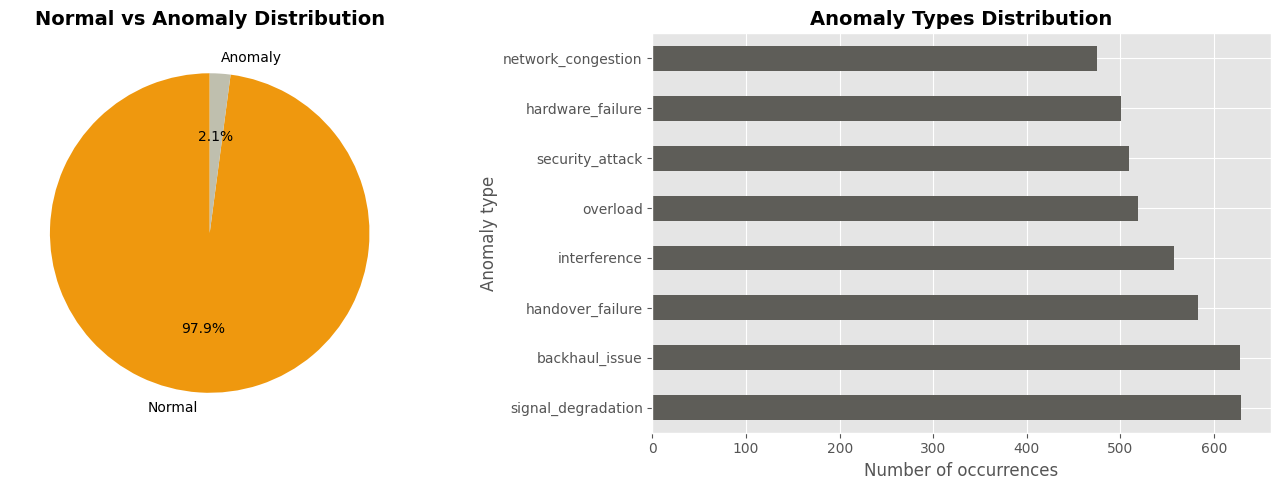

In [10]:
# Anomaly distribution
print("🚨 Anomaly distribution:")
anomaly_counts = df['anomaly'].value_counts()
print(anomaly_counts)
print(f"\n   Normal: {anomaly_counts[0]:,} ({anomaly_counts[0]/len(df)*100:.2f}%)")
print(f"   Anomalies: {anomaly_counts[1]:,} ({anomaly_counts[1]/len(df)*100:.2f}%)")

# Distribution of anomaly types
print("\n🔴 Anomaly types:")
anomaly_types = df[df['anomaly'] == 1]['anomaly_type'].value_counts()
print(anomaly_types)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Normal vs Anomaly
axes[0].pie(anomaly_counts, labels=['Normal', 'Anomaly'], autopct='%1.1f%%', 
            colors=["#ef980e", "#bfbfae"], startangle=90)
axes[0].set_title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')

# Chart 2: Anomaly types
anomaly_types.plot(kind='barh', ax=axes[1], color="#5e5d58")
axes[1].set_title('Anomaly Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of occurrences')
axes[1].set_ylabel('Anomaly type')

plt.tight_layout()
plt.show()

## 5. Slice Type Distribution

📡 Slice type distribution:
slice_type
URLLC    210528
Name: count, dtype: int64
   URLLC: 210,528 (100.0%)

🔴 Anomalies by slice type:
slice_type
URLLC    4401
dtype: int64


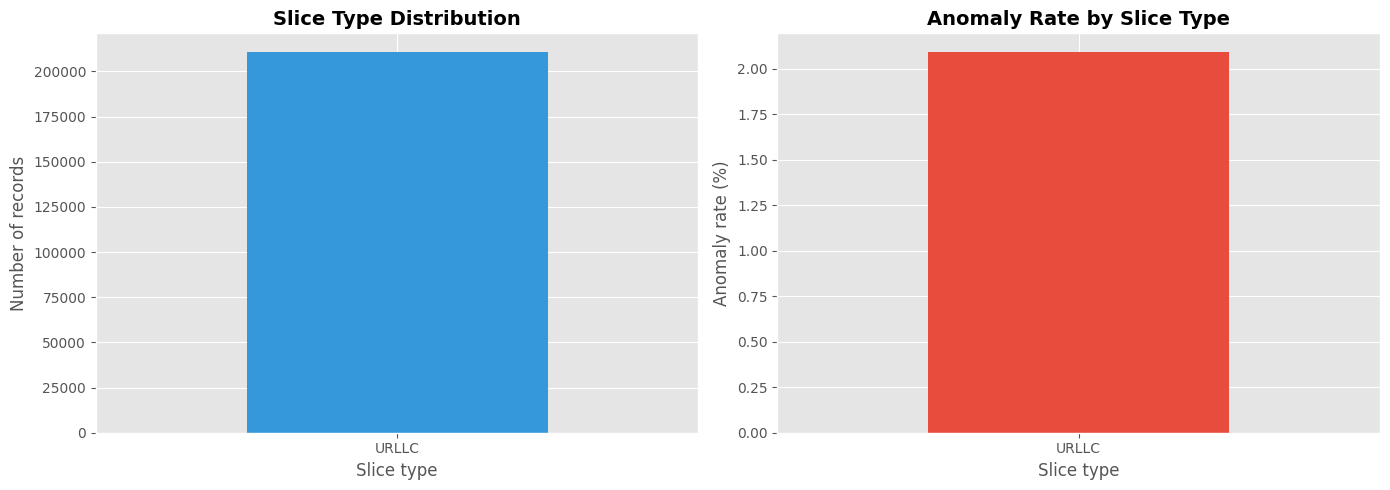

In [11]:
# Slice type distribution
print("📡 Slice type distribution:")
slice_counts = df['slice_type'].value_counts()
print(slice_counts)
for slice_type, count in slice_counts.items():
    print(f"   {slice_type}: {count:,} ({count/len(df)*100:.1f}%)")

# Anomalies by slice type
print("\n🔴 Anomalies by slice type:")
slice_anomalies = df[df['anomaly'] == 1].groupby('slice_type').size()
print(slice_anomalies)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Slice distribution
slice_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e67e22', '#9b59b6'])
axes[0].set_title('Slice Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Slice type')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Anomalies per slice
anomaly_rate_by_slice = df.groupby('slice_type')['anomaly'].mean() * 100
anomaly_rate_by_slice.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Anomaly Rate by Slice Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Slice type')
axes[1].set_ylabel('Anomaly rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. KPI Descriptive Statistics

In [12]:
# Select KPI columns (numeric)
kpi_columns = [col for col in df.columns if col not in 
               ['timestamp', 'cell_id', 'ue_id', 'slice_type', 'latitude', 
                'longitude', 'anomaly', 'anomaly_type']]

print(f"📊 Descriptive statistics for {len(kpi_columns)} KPIs:")
print(f"   KPIs: {', '.join(kpi_columns[:5])}... (+ {len(kpi_columns)-5} others)")

# Descriptive statistics
df[kpi_columns].describe()

📊 Descriptive statistics for 14 KPIs:
   KPIs: one_way_latency_ms, jitter_ms, rtt_ms, packet_delay_budget_ms, handover_interruption_time_ms... (+ 9 others)


,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule
count,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,2.105280e+05
mean,3.352123,0.581241,6.835095,0.771442,5.620053,99.506014,0.000725,0.000727,0.560275,102.473953,102.576902,9.938169,99.261579,5.037152e+08
std,10.385316,0.986210,20.629293,0.273575,8.921277,3.354005,0.002698,0.002717,0.706935,13.680199,13.611720,0.670031,2.889897,3.856475e+07
min,1.865600,0.398700,3.964000,0.676800,4.200300,35.148200,0.000400,0.000400,0.386400,0.116800,0.100000,0.539600,29.729800,5.878773e+06
25%,2.464200,0.489200,5.076800,0.738700,5.090700,99.999500,0.000500,0.000500,0.483800,99.934650,100.042875,9.782300,99.474300,4.835306e+08
50%,2.561500,0.506400,5.269000,0.750500,5.251100,99.999500,0.000500,0.000500,0.501000,104.399650,104.501900,9.993600,99.498500,5.050203e+08
75%,2.663900,0.524100,5.469000,0.762600,5.414000,99.999500,0.000500,0.000500,0.519000,108.655000,108.728700,10.200700,99.522100,5.262155e+08
max,300.000000,39.778700,600.000000,9.986100,398.717900,99.999700,0.060000,0.060000,19.844500,130.490900,131.039400,11.273400,99.634400,6.506002e+08


In [13]:
# KPI comparison: Normal vs Anomaly
#Les KPIs avec les plus grandes différences (%) sont les plus discriminants
print("📊 Average KPI comparison (Normal vs Anomaly):\n")

comparison = pd.DataFrame({
    'Normal (mean)': df[df['anomaly'] == 0][kpi_columns].mean(),
    'Anomaly (mean)': df[df['anomaly'] == 1][kpi_columns].mean(),
})
comparison['Difference (%)'] = ((comparison['Anomaly (mean)'] - comparison['Normal (mean)']) / 
                                 comparison['Normal (mean)'] * 100).round(2)

print(comparison)

# Interprétation automatique des résultats
print("\n" + "="*80)
print("🔍 INTERPRÉTATION DES RÉSULTATS")
print("="*80)

# Trier par valeur absolue de la différence
comparison_sorted = comparison.copy()
comparison_sorted['Abs_Diff'] = comparison_sorted['Difference (%)'].abs()
comparison_sorted = comparison_sorted.sort_values('Abs_Diff', ascending=False)

# Identifier les KPIs les plus discriminants
print("\n🎯 KPIs les plus discriminants (|Différence| > 50%) :")
highly_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] > 50]
if len(highly_discriminant) > 0:
    for kpi in highly_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        normal_val = comparison_sorted.loc[kpi, 'Normal (mean)']
        anomaly_val = comparison_sorted.loc[kpi, 'Anomaly (mean)']
        
        if diff > 0:
            trend = "↑ AUGMENTE"
            impact = "DÉGRADATION"
        else:
            trend = "↓ DIMINUE"
            impact = "DÉGRADATION" if "loss" in kpi.lower() or "error" in kpi.lower() else "AMÉLIORATION"
        
        print(f"   • {kpi}:")
        print(f"      Normal: {normal_val:.2f} → Anomaly: {anomaly_val:.2f} ({diff:+.1f}%)")
        print(f"      {trend} de {abs(diff):.1f}% → {impact}")
else:
    print("   Aucun KPI avec |Différence| > 50%")

print("\n🟡 KPIs modérément discriminants (20% < |Différence| < 50%) :")
moderately_discriminant = comparison_sorted[(comparison_sorted['Abs_Diff'] >= 20) & 
                                             (comparison_sorted['Abs_Diff'] <= 50)]
if len(moderately_discriminant) > 0:
    for kpi in moderately_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        print(f"   • {kpi}: {diff:+.1f}%")
else:
    print("   Aucun KPI dans cette catégorie")

print("\n🟢 KPIs peu discriminants (|Différence| < 20%) :")
low_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] < 20]
if len(low_discriminant) > 0:
    print(f"   • {len(low_discriminant)} KPI(s): {', '.join(low_discriminant.index[:5].tolist())}")
    if len(low_discriminant) > 5:
        print(f"     ... et {len(low_discriminant)-5} autres")
else:
    print("   Aucun KPI dans cette catégorie")

# Recommandations
print("\n💡 RECOMMANDATIONS :")
print(f"   ✓ Utiliser les {len(highly_discriminant)} KPIs fortement discriminants comme features principales")
print(f"   ✓ Définir des seuils d'alerte basés sur les valeurs moyennes observées")
print(f"   ✓ Les KPIs peu discriminants peuvent être exclus du modèle pour simplifier")
print(f"   ✓ Total de KPIs analysés: {len(comparison)} KPIs")

print("\n" + "="*80)

📊 Average KPI comparison (Normal vs Anomaly):

                                  Normal (mean)  Anomaly (mean)  \
one_way_latency_ms                 2.622835e+00    3.750931e+01   
jitter_ms                          5.134595e-01    3.755897e+00   
rtt_ms                             5.391365e+00    7.445421e+01   
packet_delay_budget_ms             7.563510e-01    1.478242e+00   
handover_interruption_time_ms      5.269069e+00    2.205889e+01   
reliability_percent                9.969556e+01    9.062841e+01   
packet_loss_percent                5.089008e-04    1.085047e-02   
packet_loss_rate_percent           5.089086e-04    1.093808e-02   
bler_percent                       5.070286e-01    3.054137e+00   
throughput_dl_mbps                 1.037675e+02    4.188769e+01   
throughput_ul_mbps                 1.038618e+02    4.239701e+01   
spectral_efficiency_bps_hz         9.973232e+00    8.295954e+00   
handover_success_rate_percent      9.936808e+01    9.427369e+01   
energy_efficien

## 7. Key KPI Visualization by Discrimination Level

🎯 10 KPIs très discriminants:


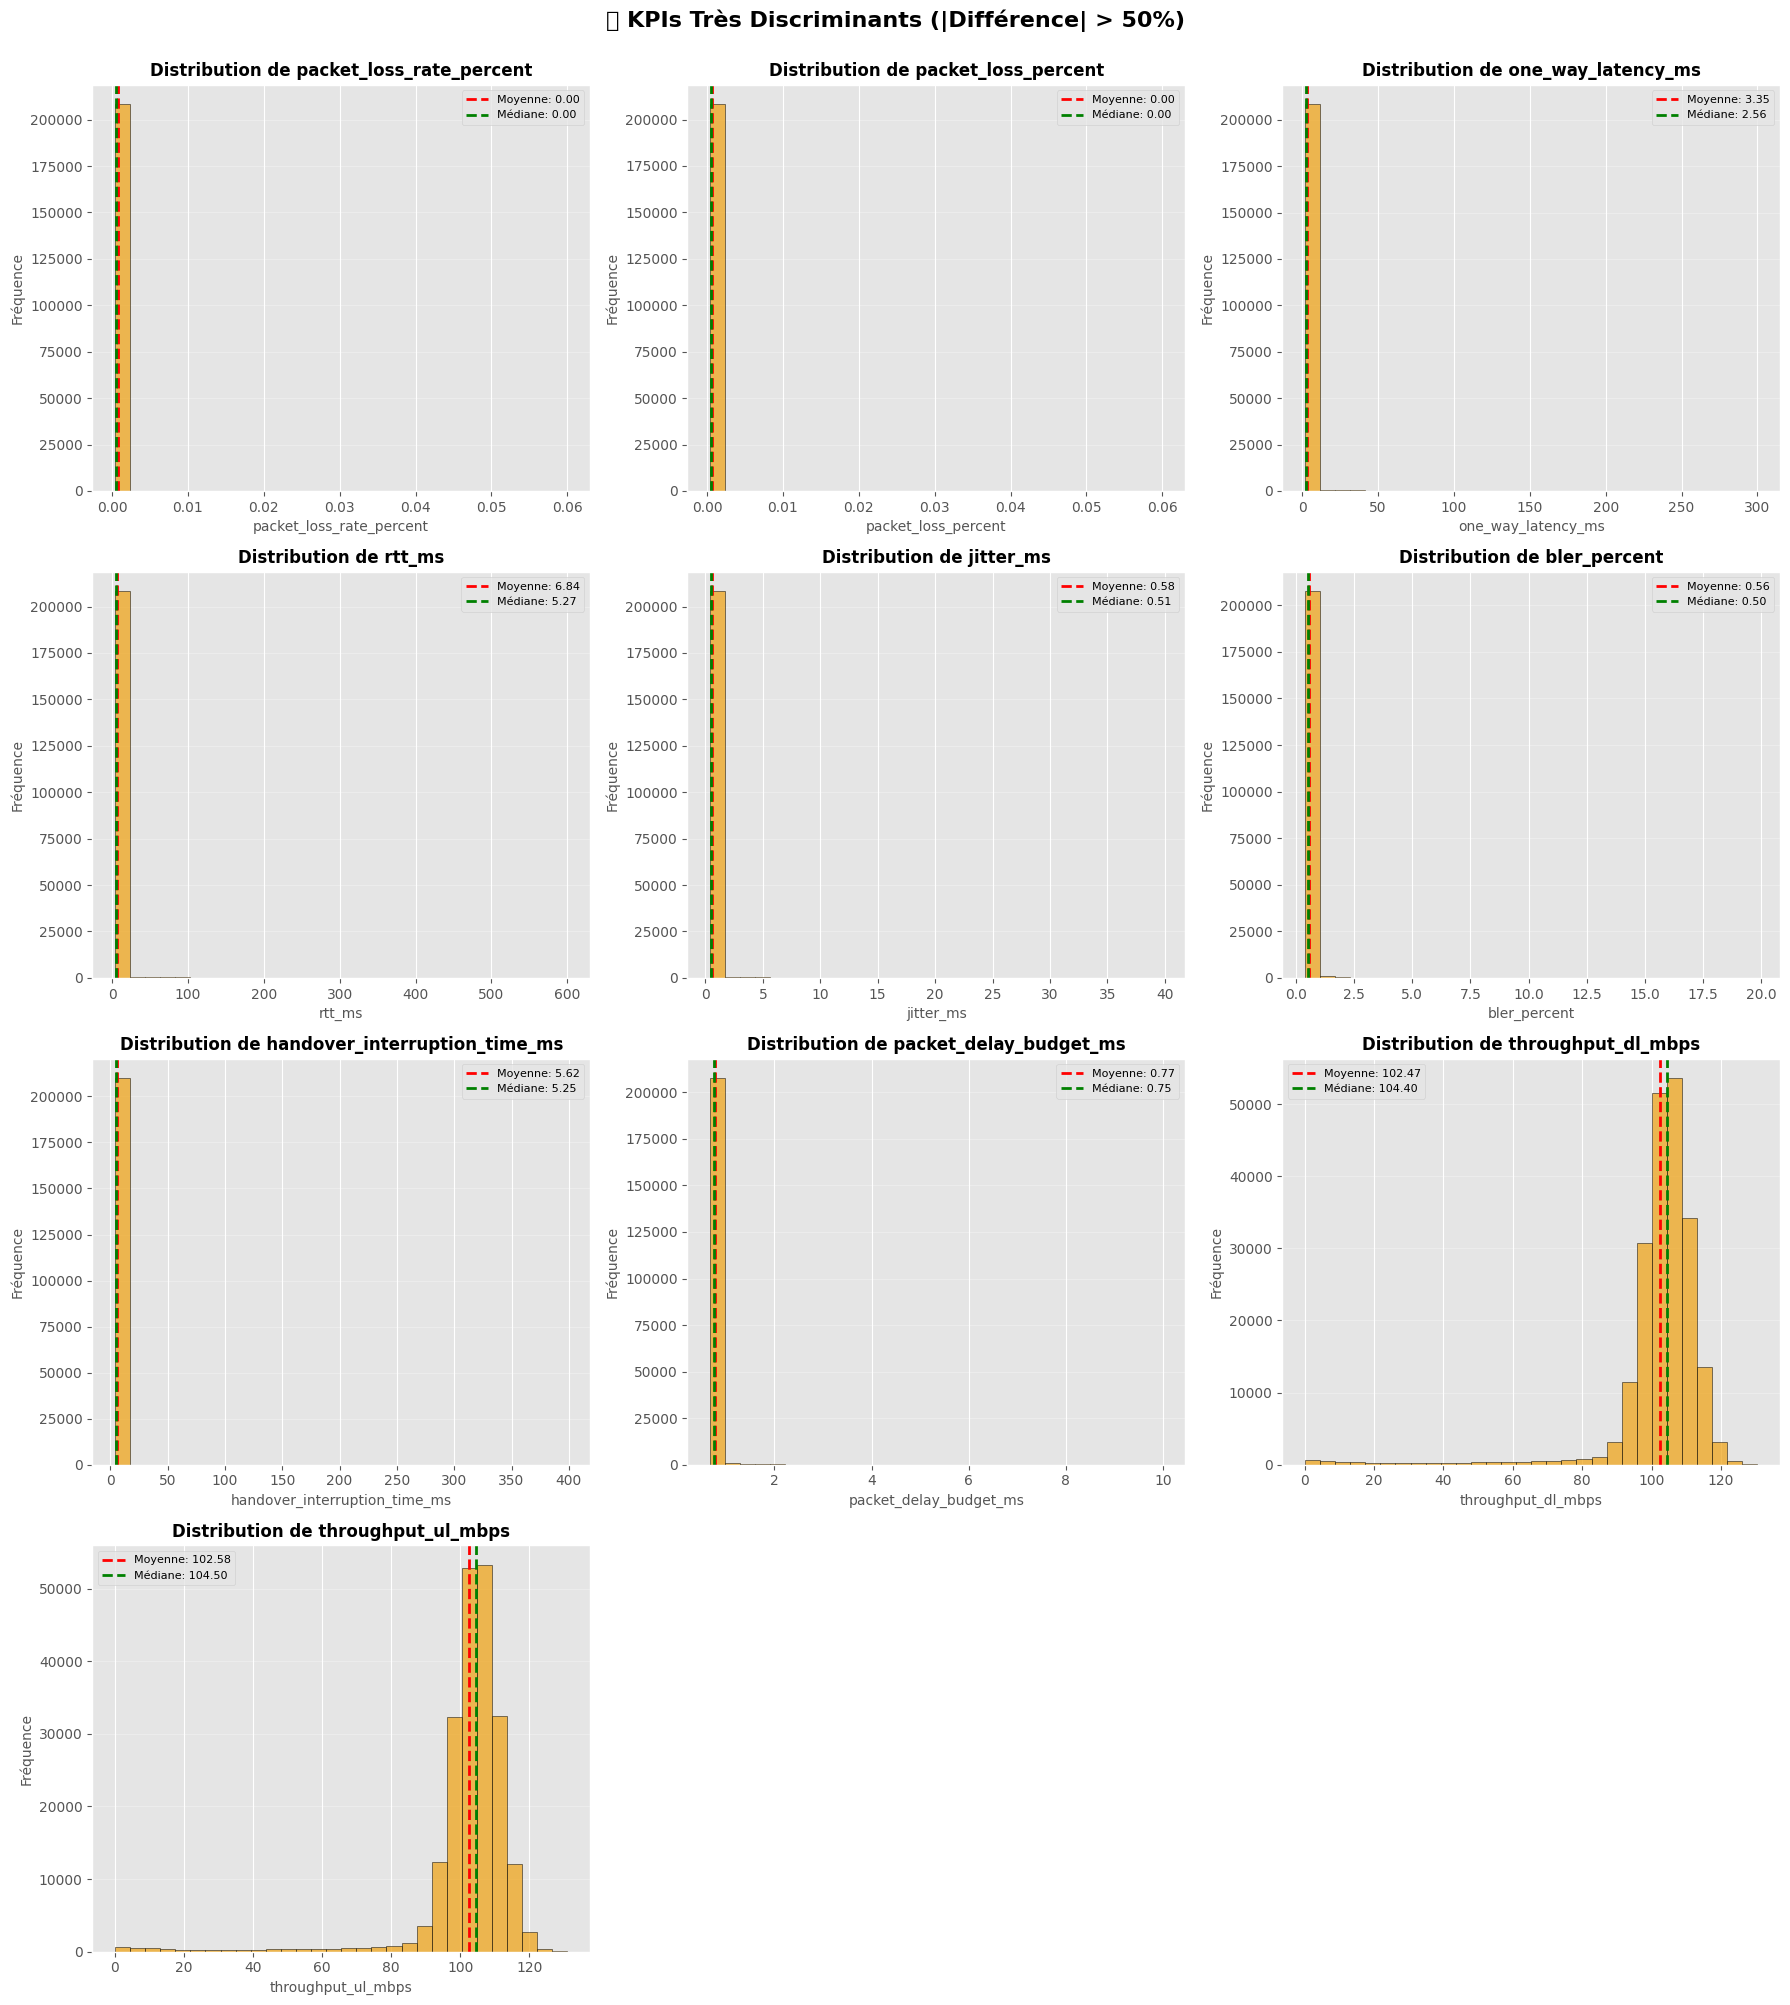


🟡 0 KPIs modérément discriminants:
⚠️ Aucun KPI dans le groupe: 🟡 KPIs Modérément Discriminants (20% < |Différence| < 50%)

🟢 4 KPIs peu discriminants:


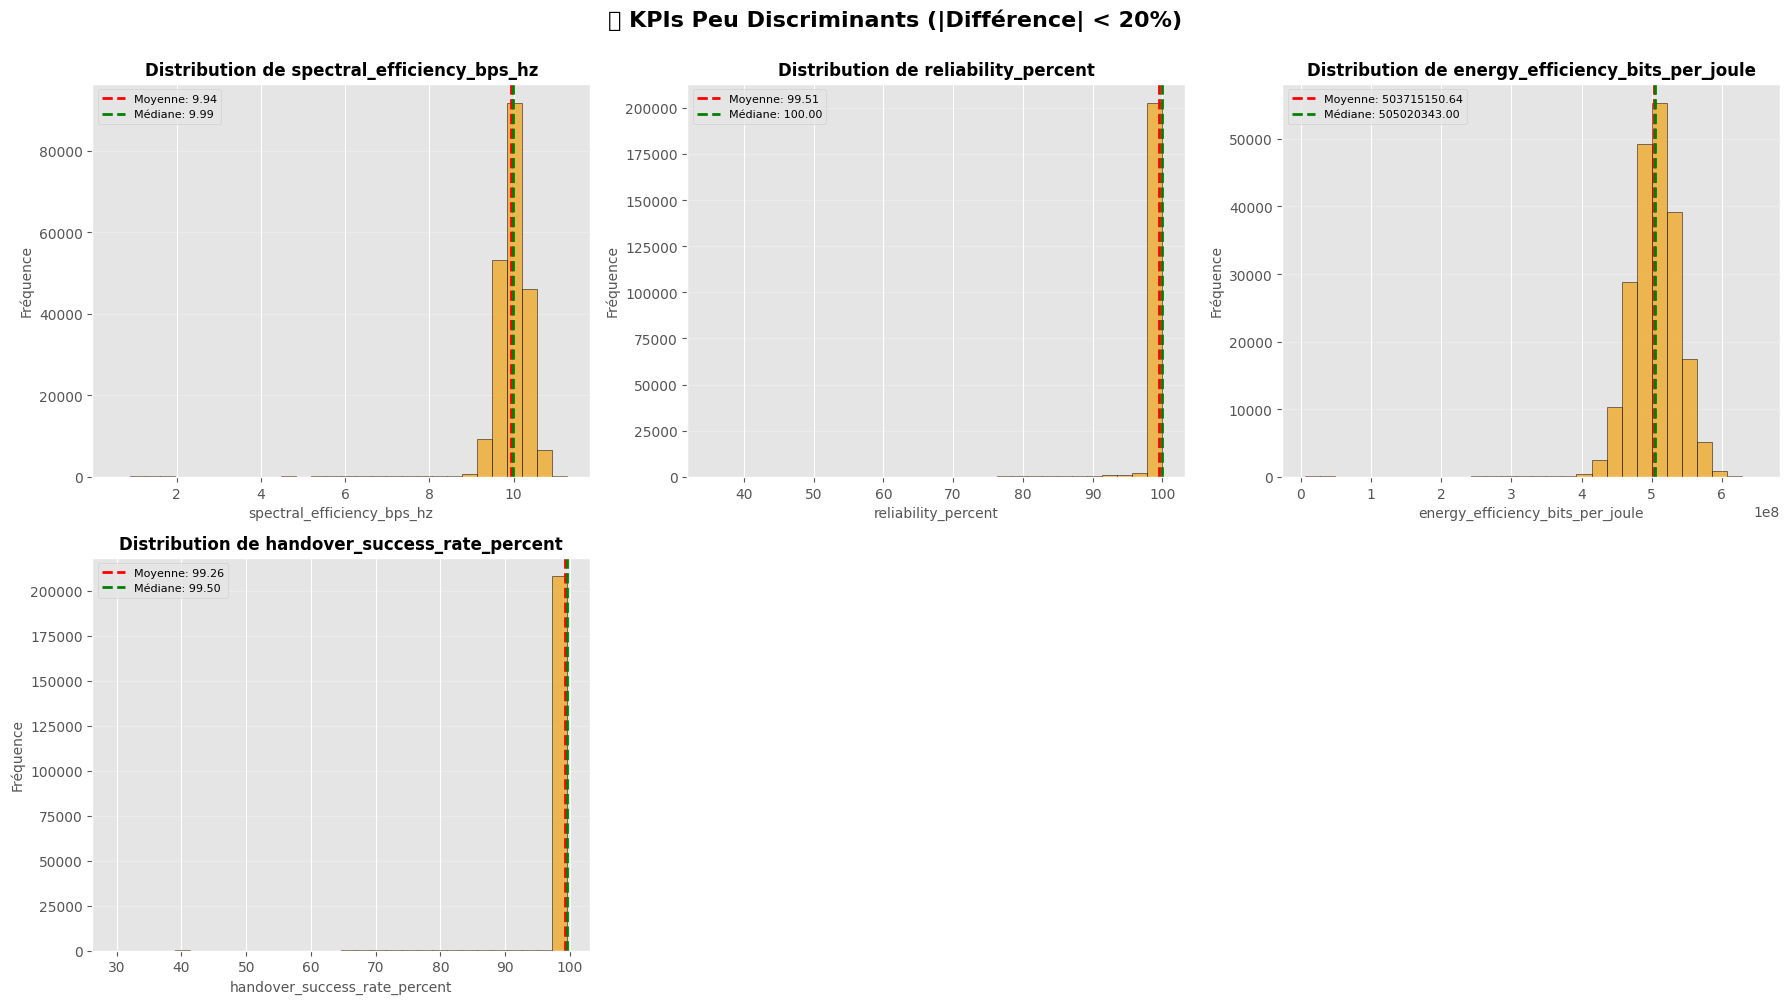

In [14]:
# =====================================================================
# Visualisation de TOUS les KPIs groupés par niveau de discrimination
# =====================================================================

# Calculer les groupes de KPIs
comparison_analysis = comparison.copy()
comparison_analysis['Abs_Diff'] = comparison_analysis['Difference (%)'].abs()

highly_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] > 50].sort_values('Abs_Diff', ascending=False).index.tolist()
moderately_discriminant_kpis = comparison_analysis[(comparison_analysis['Abs_Diff'] >= 20) & (comparison_analysis['Abs_Diff'] <= 50)].sort_values('Abs_Diff', ascending=False).index.tolist()
low_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] < 20].sort_values('Abs_Diff', ascending=False).index.tolist()

# Fonction pour créer les histogrammes d'un groupe
def plot_kpi_group(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ Aucun KPI dans le groupe: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    for idx, kpi in enumerate(kpis):
        axes[idx].hist(df[kpi], bins=30, color="#f0a10f",
                       alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution de {kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(kpi, fontsize=10)
        axes[idx].set_ylabel('Fréquence', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

        # Statistiques: moyenne et médiane
        mean_val = df[kpi].mean()
        median_val = df[kpi].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--',
                          linewidth=2, label=f'Moyenne: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--',
                          linewidth=2, label=f'Médiane: {median_val:.2f}')
        axes[idx].legend(fontsize=8)
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- BLOC 1: KPIs très discriminants (|Diff| > 50%) ---
print(f"🎯 {len(highly_discriminant_kpis)} KPIs très discriminants:")
plot_kpi_group(highly_discriminant_kpis, 
               '🎯 KPIs Très Discriminants (|Différence| > 50%)')

# --- BLOC 2: KPIs modérément discriminants (20-50%) ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} KPIs modérément discriminants:")
plot_kpi_group(moderately_discriminant_kpis, 
               '🟡 KPIs Modérément Discriminants (20% < |Différence| < 50%)')

# --- BLOC 3: KPIs peu discriminants (<20%) ---
print(f"\n🟢 {len(low_discriminant_kpis)} KPIs peu discriminants:")
plot_kpi_group(low_discriminant_kpis, 
               '🟢 KPIs Peu Discriminants (|Différence| < 20%)')



🎯 10 KPIs très discriminants (Box Plots):


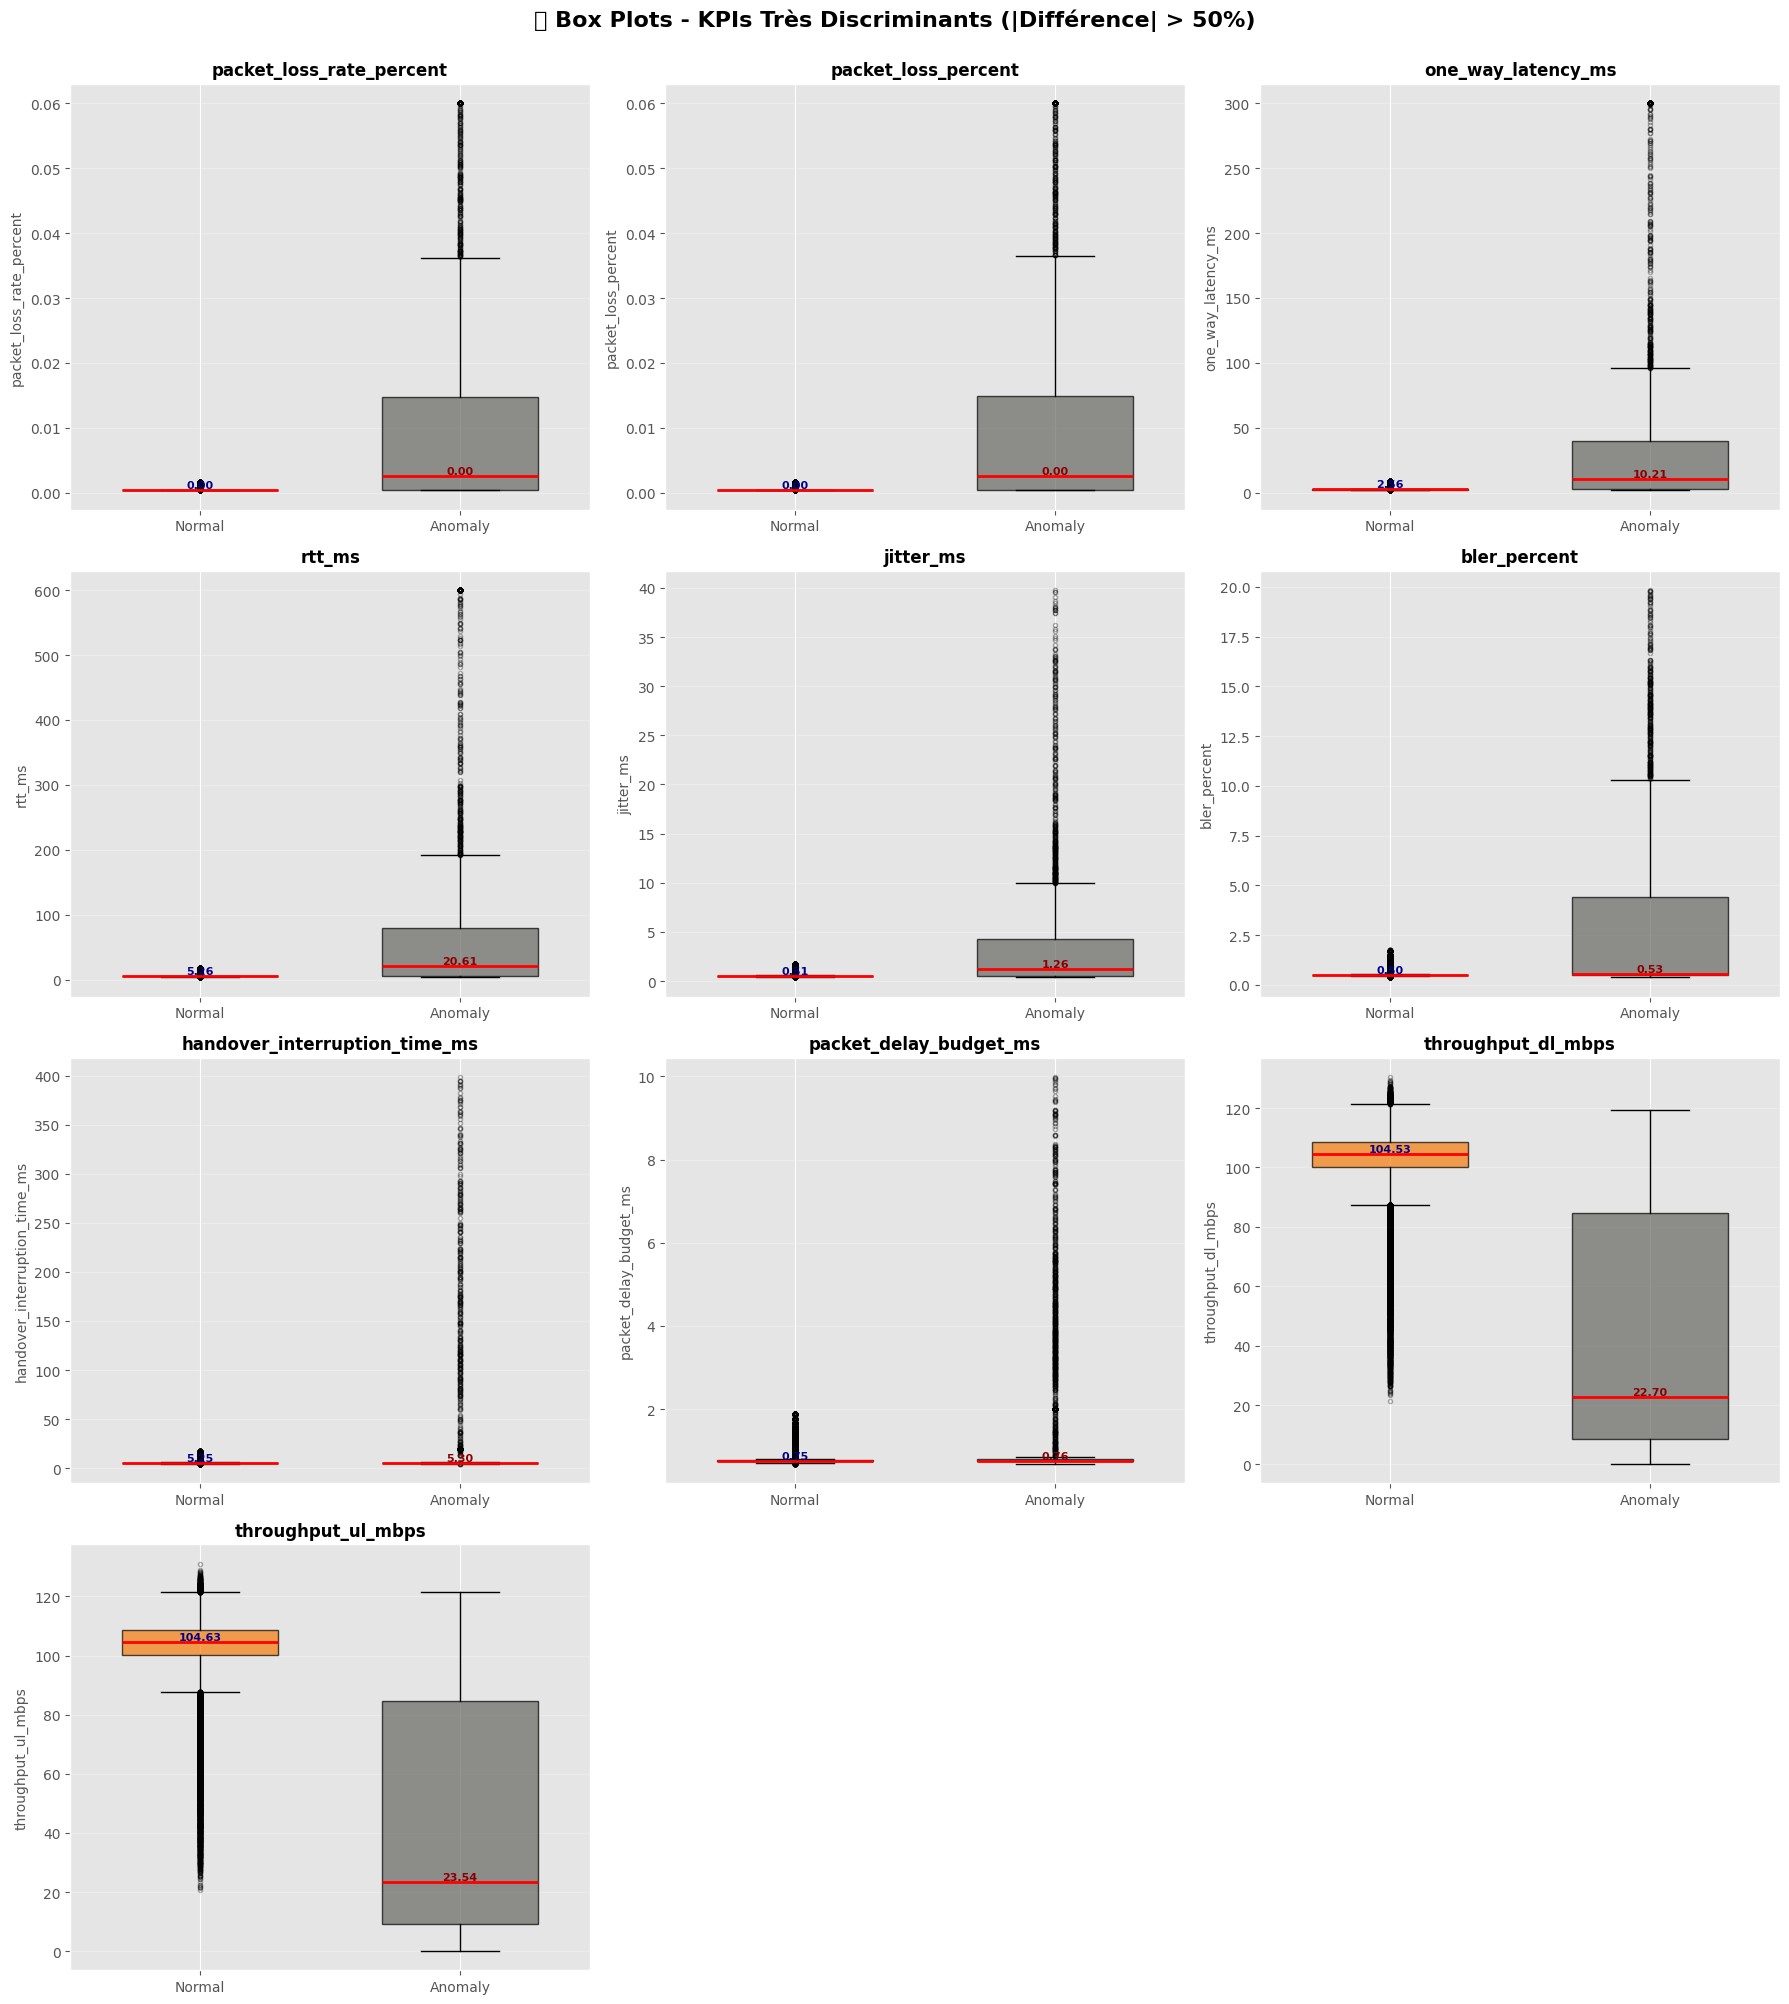


🟡 0 KPIs modérément discriminants (Box Plots):
⚠️ Aucun KPI dans le groupe: 🟡 Box Plots - KPIs Modérément Discriminants (20% < |Différence| < 50%)

🟢 4 KPIs peu discriminants (Box Plots):


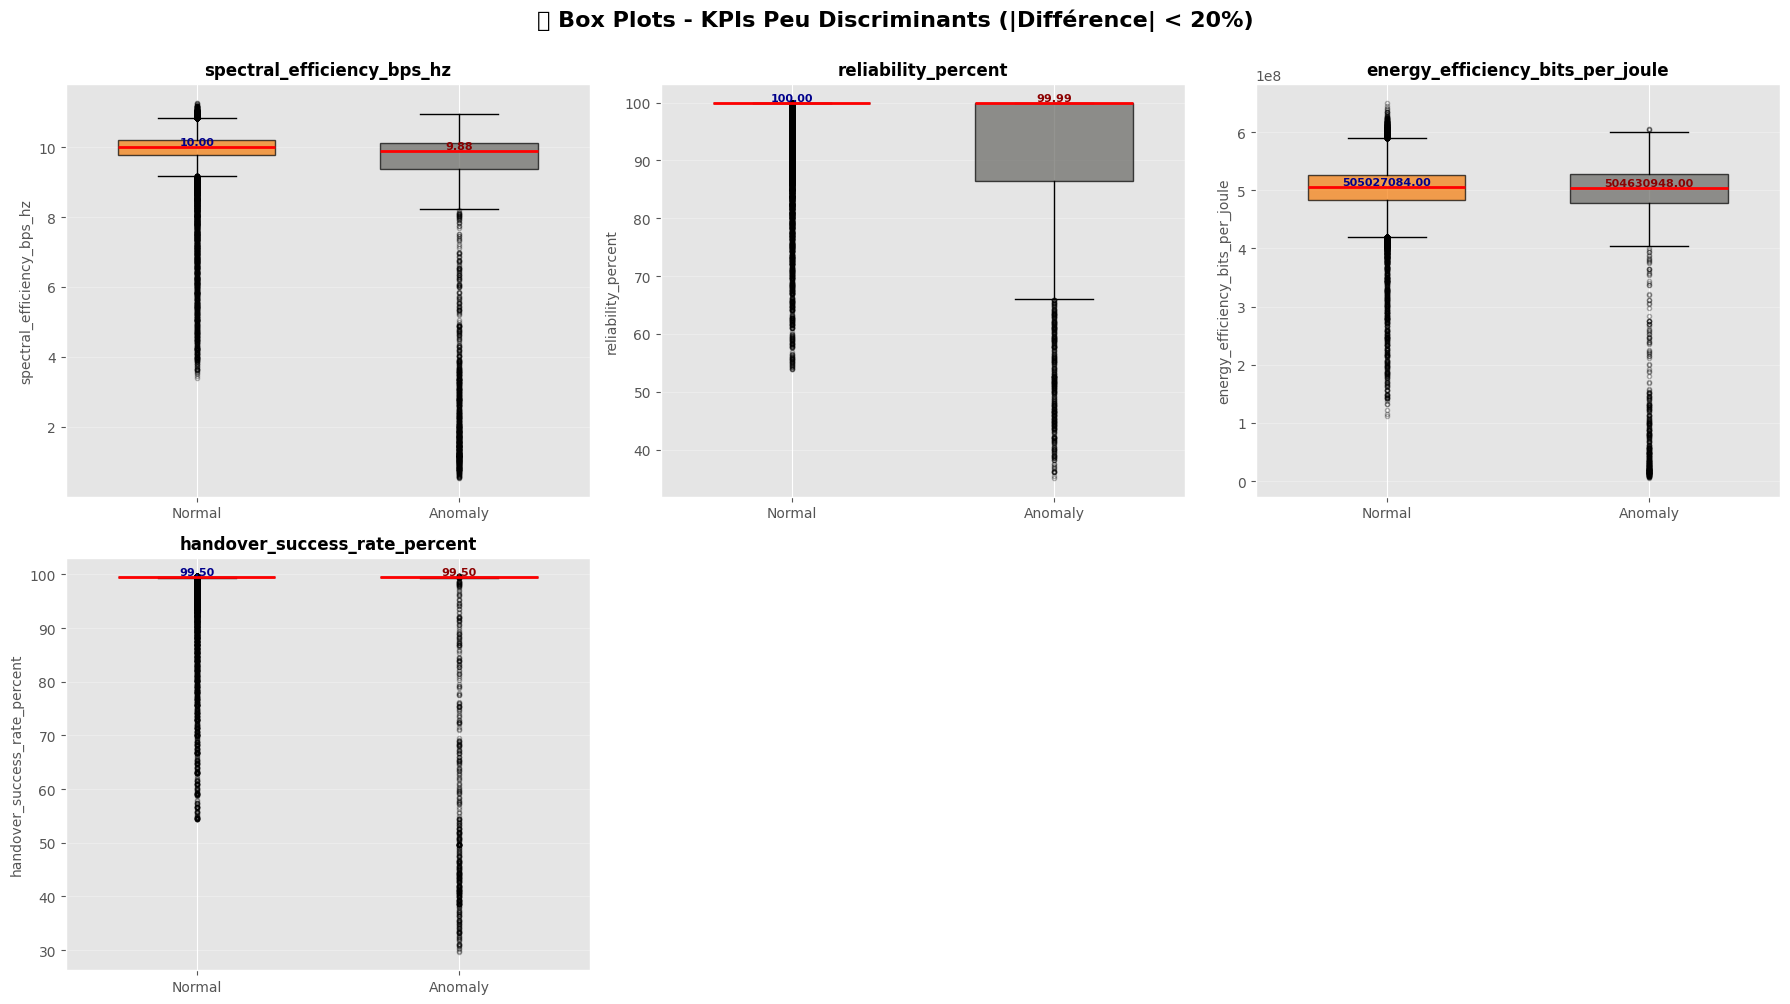

In [15]:
# =====================================================================
# Box Plots de TOUS les KPIs groupés par niveau de discrimination
# Normal vs Anomaly
# =====================================================================

def plot_kpi_boxplots(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ Aucun KPI dans le groupe: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    
    for idx, kpi in enumerate(kpis):
        data_normal = df[df['anomaly'] == 0][kpi]
        data_anomaly = df[df['anomaly'] == 1][kpi]
        
        bp = axes[idx].boxplot([data_normal, data_anomaly],
                               labels=['Normal', 'Anomaly'],
                               patch_artist=True,
                               widths=0.6,
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='o', markersize=3, alpha=0.3))
        
        # Couleurs des boîtes
        bp['boxes'][0].set_facecolor("#f67c0a")
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor("#676762")
        bp['boxes'][1].set_alpha(0.7)
        
        axes[idx].set_title(f'{kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(kpi, fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Annoter les médianes
        med_n = data_normal.median()
        med_a = data_anomaly.median()
        axes[idx].annotate(f'{med_n:.2f}', xy=(1, med_n), fontsize=8, 
                          color='darkblue', fontweight='bold', ha='center', va='bottom')
        axes[idx].annotate(f'{med_a:.2f}', xy=(2, med_a), fontsize=8, 
                          color='darkred', fontweight='bold', ha='center', va='bottom')
    
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- BLOC 1: KPIs très discriminants ---
print(f"🎯 {len(highly_discriminant_kpis)} KPIs très discriminants (Box Plots):")
plot_kpi_boxplots(highly_discriminant_kpis, 
                  '🎯 Box Plots - KPIs Très Discriminants (|Différence| > 50%)')

# --- BLOC 2: KPIs modérément discriminants ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} KPIs modérément discriminants (Box Plots):")
plot_kpi_boxplots(moderately_discriminant_kpis, 
                  '🟡 Box Plots - KPIs Modérément Discriminants (20% < |Différence| < 50%)')

# --- BLOC 3: KPIs peu discriminants ---
print(f"\n🟢 {len(low_discriminant_kpis)} KPIs peu discriminants (Box Plots):")
plot_kpi_boxplots(low_discriminant_kpis, 
                  '🟢 Box Plots - KPIs Peu Discriminants (|Différence| < 20%)')

## 7.bis Tests Statistiques 

Tests statistiques pour répondre aux questions métier clés du réseau 5G.

In [16]:
from scipy import stats

print("="*90)
print("📊 TESTS STATISTIQUES - BUSINESS UNDERSTANDING")
print("="*90)

# =====================================================================
# Q1: Les anomalies dégradent-elles SIGNIFICATIVEMENT les KPIs réseau ?
# Test de Mann-Whitney U (non paramétrique) pour chaque KPI
# =====================================================================
print("\n" + "─"*90)
print("❓ Q1: Les anomalies dégradent-elles significativement les KPIs réseau ?")
print("   Test: Mann-Whitney U (comparaison Normal vs Anomaly pour chaque KPI)")
print("─"*90)

mann_whitney_results = []
for kpi in kpi_columns:
    normal_vals = df[df['anomaly'] == 0][kpi].dropna()
    anomaly_vals = df[df['anomaly'] == 1][kpi].dropna()
    stat, p_value = stats.mannwhitneyu(normal_vals, anomaly_vals, alternative='two-sided')
    mann_whitney_results.append({
        'KPI': kpi,
        'U-Statistic': round(stat, 2),
        'P-Value': p_value,
        'Significatif (p<0.05)': '✅ OUI' if p_value < 0.05 else '❌ NON',
        'Interprétation': 'Différence significative' if p_value < 0.05 else 'Pas de différence'
    })

mw_df = pd.DataFrame(mann_whitney_results)
print(mw_df.to_string(index=False))

sig_count = sum(1 for r in mann_whitney_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_count}/{len(kpi_columns)} KPIs sont significativement différents entre Normal et Anomaly")
print(f"   → Les anomalies ont un impact statistiquement prouvé sur {sig_count} indicateurs réseau")

# =====================================================================
# Q2: Certains types de slice sont-ils plus vulnérables aux anomalies ?
# Test du Chi-deux d'indépendance (slice_type vs anomaly)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q2: Certains types de slice sont-ils plus vulnérables aux anomalies ?")
print("   Test: Chi-deux d'indépendance (slice_type × anomaly)")
print("─"*90)

contingency_table = pd.crosstab(df['slice_type'], df['anomaly'], margins=True)
print("\nTableau de contingence:")
print(contingency_table)

chi2, p_chi2, dof, expected = stats.chi2_contingency(
    pd.crosstab(df['slice_type'], df['anomaly'])
)
print(f"\n   Chi² = {chi2:.4f}")
print(f"   Degrés de liberté = {dof}")
print(f"   P-value = {p_chi2:.6f}")
print(f"   Résultat: {'✅ Dépendance significative' if p_chi2 < 0.05 else '❌ Indépendance'}")

if p_chi2 < 0.05:
    print(f"\n💡 Conclusion: Le type de slice influence SIGNIFICATIVEMENT le taux d'anomalies")
    anomaly_rates = df.groupby('slice_type')['anomaly'].mean() * 100
    most_vulnerable = anomaly_rates.idxmax()
    print(f"   → Slice la plus vulnérable: {most_vulnerable} ({anomaly_rates[most_vulnerable]:.2f}%)")
    least_vulnerable = anomaly_rates.idxmin()
    print(f"   → Slice la moins vulnérable: {least_vulnerable} ({anomaly_rates[least_vulnerable]:.2f}%)")
else:
    print(f"\n💡 Conclusion: Pas de lien significatif entre le type de slice et les anomalies")

# =====================================================================
# Q3: Y a-t-il une relation entre le type d'anomalie et le type de slice ?
# Test du Chi-deux (anomaly_type vs slice_type)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q3: Certains types d'anomalies sont-ils spécifiques à certains slices ?")
print("   Test: Chi-deux d'indépendance (anomaly_type × slice_type)")
print("─"*90)

df_anomalies = df[df['anomaly'] == 1]
contingency_anomaly_slice = pd.crosstab(df_anomalies['anomaly_type'], df_anomalies['slice_type'])
print("\nTableau de contingence (anomaly_type × slice_type):")
print(contingency_anomaly_slice)

chi2_as, p_as, dof_as, expected_as = stats.chi2_contingency(contingency_anomaly_slice)
print(f"\n   Chi² = {chi2_as:.4f}")
print(f"   P-value = {p_as:.6f}")
print(f"   Résultat: {'✅ Dépendance significative' if p_as < 0.05 else '❌ Indépendance'}")

if p_as < 0.05:
    print(f"\n💡 Conclusion: Certains types d'anomalies sont plus fréquents dans certains slices")
else:
    print(f"\n💡 Conclusion: Les anomalies se répartissent uniformément entre les slices")

# =====================================================================
# Q4: Les KPIs réseau suivent-ils une distribution normale ?
# Test de Shapiro-Wilk (sur un échantillon)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q4: Les KPIs suivent-ils une distribution normale ?")
print("   Test: Shapiro-Wilk (échantillon de 5000 observations)")
print("   → Important pour choisir les bons modèles ML")
print("─"*90)

shapiro_results = []
sample_size = min(5000, len(df))
for kpi in kpi_columns:
    sample = df[kpi].dropna().sample(n=sample_size, random_state=42)
    stat_sw, p_sw = stats.shapiro(sample)
    shapiro_results.append({
        'KPI': kpi,
        'Statistique W': round(stat_sw, 4),
        'P-Value': p_sw,
        'Distribution normale': '✅ OUI' if p_sw > 0.05 else '❌ NON'
    })

sw_df = pd.DataFrame(shapiro_results)
print(sw_df.to_string(index=False))

normal_count = sum(1 for r in shapiro_results if r['P-Value'] > 0.05)
print(f"\n💡 Conclusion: {normal_count}/{len(kpi_columns)} KPIs suivent une distribution normale")
if normal_count < len(kpi_columns) // 2:
    print(f"   → Privilégier des modèles non-paramétriques (Random Forest, KNN, etc.)")
else:
    print(f"   → Les modèles paramétriques (Régression Logistique, etc.) sont adaptés")

# =====================================================================
# Q5: Les KPIs varient-ils significativement selon le type d'anomalie ?
# Test de Kruskal-Wallis (comparaison entre tous les types d'anomalies)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q5: Les différents types d'anomalies ont-ils des signatures KPI distinctes ?")
print("   Test: Kruskal-Wallis (comparaison des KPIs entre types d'anomalies)")
print("─"*90)

kruskal_results = []
anomaly_types_list = df_anomalies['anomaly_type'].unique()

for kpi in kpi_columns:
    groups = [df_anomalies[df_anomalies['anomaly_type'] == at][kpi].dropna() 
              for at in anomaly_types_list]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat_kw, p_kw = stats.kruskal(*groups)
        kruskal_results.append({
            'KPI': kpi,
            'H-Statistic': round(stat_kw, 2),
            'P-Value': p_kw,
            'Significatif': '✅ OUI' if p_kw < 0.05 else '❌ NON'
        })

kw_df = pd.DataFrame(kruskal_results)
print(kw_df.to_string(index=False))

sig_kw = sum(1 for r in kruskal_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_kw}/{len(kruskal_results)} KPIs varient significativement selon le type d'anomalie")
if sig_kw > len(kruskal_results) // 2:
    print(f"   → Les types d'anomalies ont des signatures réseau DISTINCTES")
    print(f"   → Un modèle multi-classes peut identifier le TYPE d'anomalie (pas seulement sa présence)")
else:
    print(f"   → Les types d'anomalies sont difficiles à distinguer par les KPIs")


# =====================================================================
# RÉSUMÉ GLOBAL
# =====================================================================
print("\n" + "="*90)
print("📋 RÉSUMÉ GLOBAL DES TESTS STATISTIQUES")
print("="*90)
print(f"\n   Q1 - Impact des anomalies sur les KPIs:     {sig_count}/{len(kpi_columns)} KPIs impactés significativement")
print(f"   Q2 - Vulnérabilité par slice:                {'OUI - différences significatives' if p_chi2 < 0.05 else 'NON - pas de différence'}")
print(f"   Q3 - Anomalies spécifiques par slice:        {'OUI - dépendance significative' if p_as < 0.05 else 'NON - répartition uniforme'}")
print(f"   Q4 - Normalité des KPIs:                     {normal_count}/{len(kpi_columns)} KPIs normaux")
print(f"   Q5 - Signatures distinctes par type anomalie: {sig_kw}/{len(kruskal_results)} KPIs discriminants")



📊 TESTS STATISTIQUES - BUSINESS UNDERSTANDING

──────────────────────────────────────────────────────────────────────────────────────────
❓ Q1: Les anomalies dégradent-elles significativement les KPIs réseau ?
   Test: Mann-Whitney U (comparaison Normal vs Anomaly pour chaque KPI)
──────────────────────────────────────────────────────────────────────────────────────────
                             KPI  U-Statistic       P-Value Significatif (p<0.05)           Interprétation
              one_way_latency_ms  155840627.5  0.000000e+00                 ✅ OUI Différence significative
                       jitter_ms  203961247.5  0.000000e+00                 ✅ OUI Différence significative
                          rtt_ms  159648961.0  0.000000e+00                 ✅ OUI Différence significative
          packet_delay_budget_ms  352267474.0 2.789698e-142                 ✅ OUI Différence significative
   handover_interruption_time_ms  395205075.5  1.727466e-48                 ✅ OUI Différence

## 8. Correlation Matrix

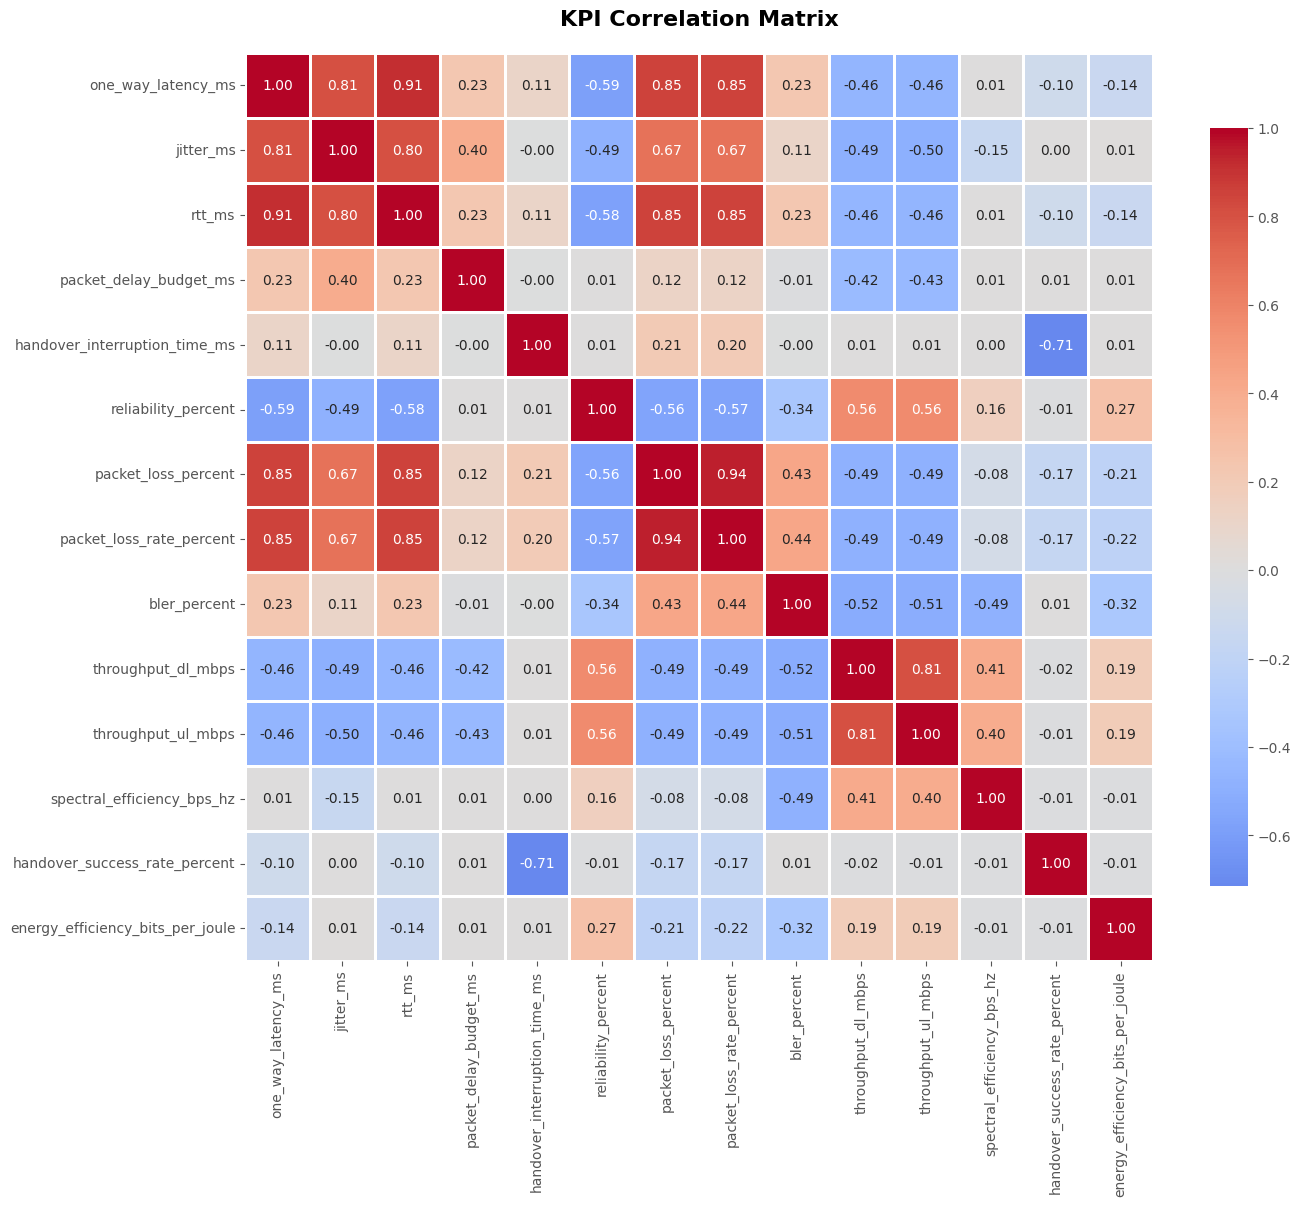


🔗 Strong correlations (|r| > 0.7):
                        KPI 1                         KPI 2  Correlation
           one_way_latency_ms                     jitter_ms        0.811
           one_way_latency_ms                        rtt_ms        0.914
           one_way_latency_ms           packet_loss_percent        0.854
           one_way_latency_ms      packet_loss_rate_percent        0.854
                    jitter_ms                        rtt_ms        0.804
                       rtt_ms           packet_loss_percent        0.847
                       rtt_ms      packet_loss_rate_percent        0.851
handover_interruption_time_ms handover_success_rate_percent       -0.714
          packet_loss_percent      packet_loss_rate_percent        0.942
           throughput_dl_mbps            throughput_ul_mbps        0.806


In [17]:
# KPI correlation matrix
correlation_matrix = df[kpi_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('KPI Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify strongest correlations (>0.7 or <-0.7)
print("\n🔗 Strong correlations (|r| > 0.7):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'KPI 1': correlation_matrix.columns[i],
                'KPI 2': correlation_matrix.columns[j],
                'Correlation': round(correlation_matrix.iloc[i, j], 3)
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlation detected.")

## 9. Temporal Analysis

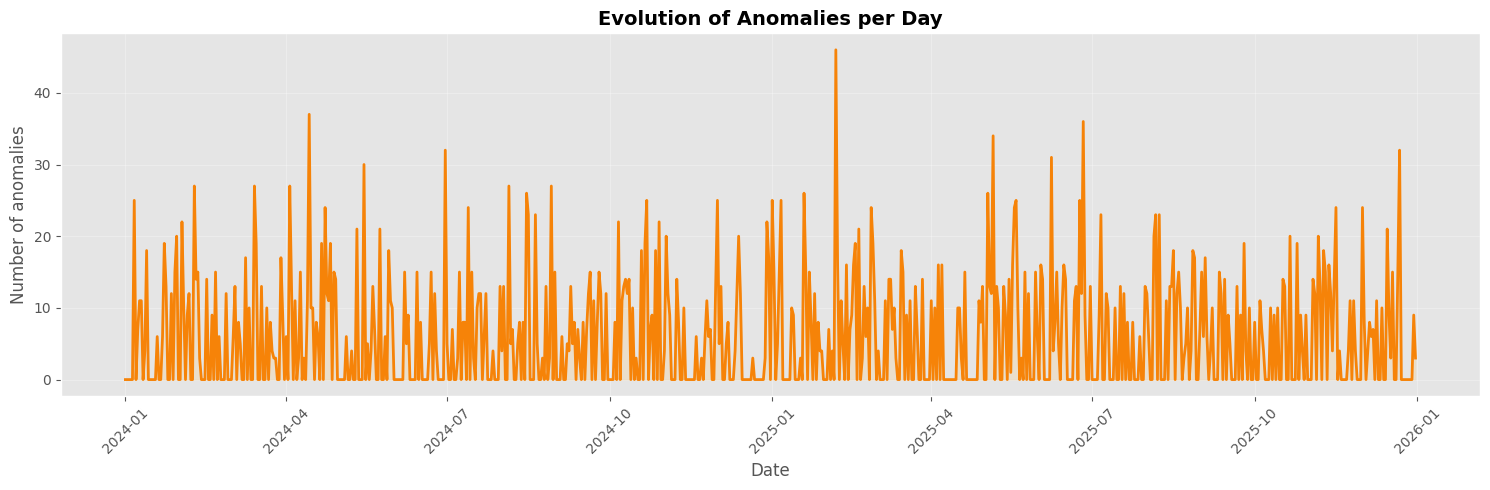

📅 Temporal statistics:
   Period covered: 2024-01-01 to 2025-12-31
   Number of days: 731
   Average anomaly rate per day: 2.09%


In [18]:
# Temporal evolution of anomalies
df['date'] = df['timestamp'].dt.date

# Anomalies per day
daily_anomalies = df.groupby('date')['anomaly'].agg(['sum', 'count'])
daily_anomalies['rate'] = (daily_anomalies['sum'] / daily_anomalies['count'] * 100)

# Visualization
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily_anomalies.index, daily_anomalies['sum'], color="#f68308", linewidth=2)
ax.fill_between(daily_anomalies.index, daily_anomalies['sum'], alpha=0.3, color="#F6CF8F")
ax.set_title('Evolution of Anomalies per Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of anomalies')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📅 Temporal statistics:")
print(f"   Period covered: {df['date'].min()} to {df['date'].max()}")
print(f"   Number of days: {df['date'].nunique()}")
print(f"   Average anomaly rate per day: {daily_anomalies['rate'].mean():.2f}%")